<a href="https://colab.research.google.com/github/damionhu-star/467/blob/main/homework_3_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EE P595 Homework 3: Identifying Malicious URLs (PyTorch)

<span style="color:red">**Released Date: February 5, 2026**</span>  
<span style="color:red">**Due Date: February 22, 2026**</span>

Build a 1D CNN to classify malicious HTTP request URLs using N-gram embeddings.

**Key Concepts:** N-gram extraction, Co-occurrence matrix, TruncatedSVD, 1D CNN

**Teammate:** _(Name if applicable)_

In [1]:
%pip install torch tqdm assertpy scikit-learn pandas matplotlib

  Preparing metadata (setup.py) ... done
  Created wheel for assertpy: filename=assertpy-1.1-py3-none-any.whl size=42897 sha256=3fd68d877c4dbf768e70ca2b50d647634f3c9c98ddf14cafa23212990d391e60
  Stored in directory: /root/.cache/pip/wheels/e9/a6/9e/a5cead15269b79ab7ebf051cfc3f7adcbd5a880e683e94736a
Successfully built assertpy


## 1. Data Loading

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load WAF URLs dataset
df = pd.read_csv('./waf-urls.csv')
print(f'Dataset: {len(df)} URLs')

# Split: 60% train, 20% val, 20% test
urls_tv, urls_test, labels_tv, labels_test = train_test_split(
    df['url'], df['label'], test_size=0.2, random_state=12345)
urls_train, urls_vali, labels_train, labels_vali = train_test_split(
    urls_tv, labels_tv, test_size=0.25, random_state=12345)

print(f'Train: {len(urls_train)}, Val: {len(urls_vali)}, Test: {len(urls_test)}')

Dataset: 60547 URLs
Train: 36327, Val: 12110, Test: 12110


## 2. N-Gram Functions

In [11]:
from assertpy import assert_that
from tqdm import tqdm

def iter_ngrams(text, n, start_symbol='\x00', end_symbol='\x01'):
    """Generate N-grams with start/end padding."""
    padded = (start_symbol * (n - 1)) + text + (end_symbol * n)
    for i in range(len(padded) - n + 1):
        yield padded[i:i + n]
# Test
assert_that(list(iter_ngrams('/test', n=3))).is_equal_to([
    '\x00\x00/', '\x00/t', '/te', 'tes', 'est', 'st\x01', 't\x01\x01', '\x01\x01\x01'
])

In [12]:
def build_ngram_mapping(urls, n, rare_threshold=2):
    ngram_count = {}

    print('Counting N-grams...')
    for url in tqdm(urls):
        for ngram in iter_ngrams(url, n):
            ngram_count[ngram] = ngram_count.get(ngram, 0) + 1

    n2i, i2n = {}, []
    n_rare = 0

    print('Building mapping...')
    for ngram, count in tqdm(ngram_count.items()):
        if count >= rare_threshold:
            n2i[ngram] = len(i2n)
            i2n.append(ngram)
        else:
            n_rare += 1

    print(f'Unique: {len(ngram_count)}, Kept: {len(i2n)}, Rare: {n_rare}')
    return n2i, i2n

## 3. Co-occurrence Matrix

In [13]:
def build_cooccurrence_matrix(urls, n, n2i_mapping, window_size):
    n_ngram = len(n2i_mapping)
    unknown_idx = n_ngram
    co_matrix = dok_matrix((n_ngram + 1, n_ngram + 1))

    print('Building co-occurrence...')
    for url in tqdm(urls):
        prev_indices = []
        for ngram in iter_ngrams(url, n):
            idx = n2i_mapping.get(ngram, unknown_idx)
            for prev_idx in prev_indices[-window_size:]:
                co_matrix[idx, prev_idx] += 1
                co_matrix[prev_idx, idx] += 1
            prev_indices.append(idx)

    print('Normalizing...')
    row_sums = np.array(co_matrix.sum(axis=1)).flatten()
    for (i, j) in tqdm(list(co_matrix.keys())):
        if row_sums[i] > 0:
            co_matrix[i, j] /= row_sums[i]

    return co_matrix

In [18]:
from scipy.sparse import dok_matrix
import numpy as np

def build_cooccurrence_matrix(urls, n, n2i_mapping, window_size):
    n_ngram = len(n2i_mapping)
    unknown_idx = n_ngram
    co_matrix = dok_matrix((n_ngram + 1, n_ngram + 1))

    print('Building co-occurrence...')
    for url in tqdm(urls):
        prev_indices = []
        for ngram in iter_ngrams(url, n):
            idx = n2i_mapping.get(ngram, unknown_idx)
            for prev_idx in prev_indices[-window_size:]:
                co_matrix[idx, prev_idx] += 1
                co_matrix[prev_idx, idx] += 1
            prev_indices.append(idx)

    print('Normalizing...')
    row_sums = np.array(co_matrix.sum(axis=1)).flatten()
    for (i, j) in tqdm(list(co_matrix.keys())):
        if row_sums[i] > 0:
            co_matrix[i, j] /= row_sums[i]

    return co_matrix

N = 4
WINDOW_SIZE = 5

n2i_urls, i2n_urls = build_ngram_mapping(urls_train, N)
cooccurrence_urls = build_cooccurrence_matrix(urls_train, N, n2i_urls, WINDOW_SIZE)
print(f'Co-occurrence shape: {cooccurrence_urls.shape}')

Counting N-grams...


100%|██████████| 36327/36327 [00:01<00:00, 19179.17it/s]


Building mapping...


100%|██████████| 160195/160195 [00:00<00:00, 952869.68it/s]


Unique: 160195, Kept: 82844, Rare: 77351
Building co-occurrence...


100%|██████████| 36327/36327 [08:58<00:00, 67.43it/s]


Normalizing...


100%|██████████| 2542234/2542234 [01:00<00:00, 42052.66it/s]

Co-occurrence shape: (82845, 82845)


In [19]:
# Build N-gram mapping and co-occurrence matrix
N = 4
WINDOW_SIZE = 5

n2i_urls, i2n_urls = build_ngram_mapping(urls_train, N)
cooccurrence_urls = build_cooccurrence_matrix(urls_train, N, n2i_urls, WINDOW_SIZE)
print(f'Co-occurrence shape: {cooccurrence_urls.shape}')

Counting N-grams...


100%|██████████| 36327/36327 [00:00<00:00, 42293.96it/s]


Building mapping...


100%|██████████| 160195/160195 [00:00<00:00, 2171152.39it/s]


Unique: 160195, Kept: 82844, Rare: 77351
Building co-occurrence...


  4%|▍         | 1536/36327 [00:22<08:25, 68.89it/s]


KeyboardInterrupt: 

## 4. Embedding via TruncatedSVD

In [20]:
from sklearn.decomposition import TruncatedSVD

EMBEDDING_DIMS = 10

## [ TODO 4 ] Create TruncatedSVD and fit_transform co-occurrence matrix
# svd = TruncatedSVD(n_components=EMBEDDING_DIMS, n_iter=20, random_state=42)
# embedding_svd = svd.fit_transform(cooccurrence_urls)
embedding_svd = svd = TruncatedSVD(n_components=EMBEDDING_DIMS, n_iter=20, random_state=42)
embedding_svd = svd.fit_transform(cooccurrence_urls)

assert embedding_svd.shape == (len(n2i_urls)+1, EMBEDDING_DIMS)

## 5. PyTorch Model

In [21]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [22]:
def transform_urls(urls, padded_len, n, n2i_mapping, pad_symbol='\x01'):
    """Convert URLs to N-gram index sequences."""
    batch = np.empty((len(urls), padded_len + n), dtype=int)
    unknown_idx = len(n2i_mapping)

    for i, url in enumerate(urls):
        url = url[:padded_len].ljust(padded_len, pad_symbol)
        for j, ngram in enumerate(iter_ngrams(url, n)):
            batch[i, j] = n2i_mapping.get(ngram, unknown_idx)

    return batch

In [23]:
class URLDataset(Dataset):
    def __init__(self, urls, labels, padded_len, n, n2i_mapping):
        self.data = transform_urls(list(urls), padded_len, n, n2i_mapping)
        self.labels = labels.values.astype(np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.tensor(self.data[idx], dtype=torch.long), torch.tensor(self.labels[idx])

In [24]:
class URLCNN(nn.Module):
    def __init__(self, n_ngram, embedding_weights, dropout=0.25):
        super().__init__()
        embed_dim = embedding_weights.shape[1]

        weight_tensor = torch.tensor(embedding_weights, dtype=torch.float32)
        self.embedding = nn.Embedding.from_pretrained(weight_tensor, freeze=True)

        self.conv1 = nn.Conv1d(embed_dim, 20, kernel_size=5, padding=2)
        self.pool1 = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(20, 40, kernel_size=5, padding=2)
        self.pool2 = nn.MaxPool1d(5)
        self.conv3 = nn.Conv1d(40, 80, kernel_size=5, padding=2)
        self.pool3 = nn.MaxPool1d(5)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

        self.fc1 = nn.Linear(160, 16)
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = self.relu(self.conv1(x))
        x = self.pool1(x)
        x = self.relu(self.conv2(x))
        x = self.pool2(x)
        x = self.relu(self.conv3(x))
        x = self.pool3(x)
        x = self.dropout(x)
        x = x.flatten(1)
        x = self.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x)).squeeze(1)
        return x

In [25]:
# Hyperparameters
BATCH_SIZE = 256
MAX_URL_LEN = 96
N_EPOCHS = 10

# Create datasets
train_dataset = URLDataset(urls_train, labels_train, MAX_URL_LEN, N, n2i_urls)
val_dataset = URLDataset(urls_vali, labels_vali, MAX_URL_LEN, N, n2i_urls)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

model = URLCNN(len(n2i_urls), embedding_svd).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters())

In [28]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        ## [ TODO 7 ] Training step
        # optimizer.zero_grad(), forward, loss, backward, step
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct += ((out > 0.5) == y).sum().item()
        total += len(y)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            total_loss += criterion(out, y).item() * len(y)
            correct += ((out > 0.5) == y).sum().item()
            total += len(y)
    return total_loss / total, correct / total

In [29]:
# Training loop
history = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(N_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    history['loss'].append(train_loss)
    history['acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    print(f'Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}')

torch.save(model.state_dict(), './model-url-cnn.pt')

Epoch 1: Train Acc=0.7646, Val Acc=0.8945
Epoch 2: Train Acc=0.8973, Val Acc=0.9145
Epoch 3: Train Acc=0.9071, Val Acc=0.9209
Epoch 4: Train Acc=0.9143, Val Acc=0.9231
Epoch 5: Train Acc=0.9218, Val Acc=0.9295
Epoch 6: Train Acc=0.9280, Val Acc=0.9353
Epoch 7: Train Acc=0.9310, Val Acc=0.9300
Epoch 8: Train Acc=0.9331, Val Acc=0.9410
Epoch 9: Train Acc=0.9342, Val Acc=0.9318
Epoch 10: Train Acc=0.9385, Val Acc=0.9420


## 6. Evaluation

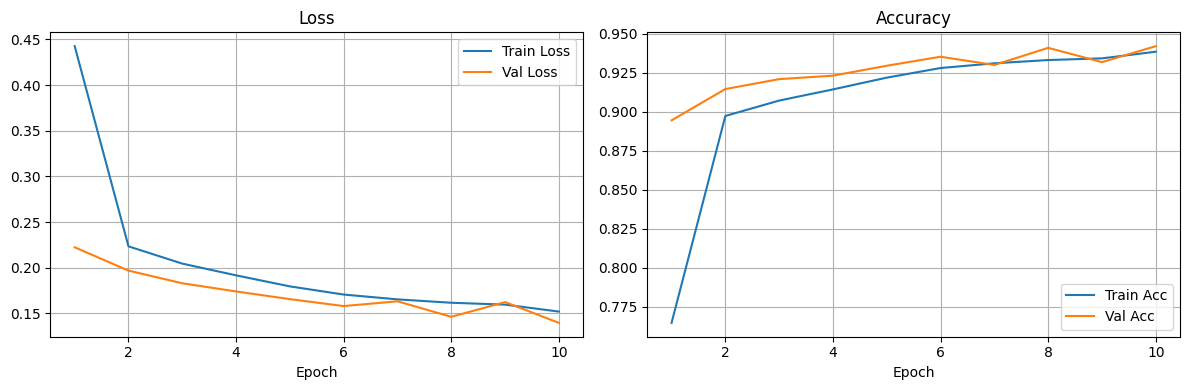

In [30]:
import matplotlib.pyplot as plt

## [ TODO 8 ] Plot loss and accuracy curves
epochs = range(1, N_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(epochs, history['loss'],     label='Train Loss')
ax1.plot(epochs, history['val_loss'], label='Val Loss')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(True)
ax2.plot(epochs, history['acc'],     label='Train Acc')
ax2.plot(epochs, history['val_acc'], label='Val Acc')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.show()

In [31]:
from sklearn.metrics import confusion_matrix, classification_report

## [ TODO 9 ] Test evaluation
# - Create test dataset and loader
# - Predict and collect results
# - Print confusion matrix and classification report
test_dataset = URLDataset(urls_test, labels_test, MAX_URL_LEN, N, n2i_urls)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        out = model(x.to(device))
        all_preds.extend((out.cpu() > 0.5).int().tolist())
        all_labels.extend(y.int().tolist())

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['Benign', 'Malicious']))

Confusion Matrix:
[[6700  443]
 [ 314 4653]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.94      0.95      7143
   Malicious       0.91      0.94      0.92      4967

    accuracy                           0.94     12110
   macro avg       0.93      0.94      0.94     12110
weighted avg       0.94      0.94      0.94     12110



## Questions

**Q1: Analyze model performance. Does lower loss indicate higher accuracy?** (2 pts)

**Your Answer:** Q1: Analyze model performance. Does lower loss indicate higher accuracy?
Not always! Loss and accuracy measure different things. Loss is continuous and tracks how confident the model is in its predictions, while accuracy just checks if the prediction crossed the 0.5 threshold or not. So you can have loss going down while accuracy stays flat if the model is getting more confident but not actually flipping any predictions. In practice they tend to move together but its not guaranteed, especially near the end of training.



**Q2: Is large window_size (e.g., 50) good? Other compression methods?** (2 pts)

**Your Answer:**

A huge window like 50 is actually pretty bad. If almost every ngram co-occurs with every other ngram in the URL, the matrix becomes really uniform and you lose the local patterns that make the embeddings useful. A smaller window around 5-10 works better since it captures nearby context without drowning out the signal.
As for other compression methods, there are a few good options. GloVe style weighted co-occurrence would down-weight distant pairs so closer ngrams matter more. Word2Vec learns embeddings through a prediction task instead of matrix math which often gives better structure. NMF is another factorization approach that keeps values non-negative which can be easier to interpret. Random projections are also an option if speed matters more than quality.



## Submission
Submit: `homework-3-student-20260205.ipynb` + `model-url-cnn.pt`